# 🃏 Playing Cards Detection menggunakan YOLOv8
**UAS Analisis Data Tidak Terstruktur — PTA 2025/2026**  
Program Studi S1 Statistika, Universitas Indonesia

**Dataset:** Playing Cards — Roboflow Universe (Augmented Startups)  
**Model:** YOLOv8 (Ultralytics)  
**Task:** Object Detection

---

## 0. Cek GPU
Pastikan runtime menggunakan GPU: **Runtime > Change runtime type > T4 GPU**

In [ ]:
import torch
print(f'CUDA available : {torch.cuda.is_available()}')
print(f'Device         : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')

CUDA available : True
Device         : Tesla T4


---
## 1. Instalasi Library

In [ ]:
!pip install ultralytics roboflow -q
!pip install opencv-python-headless matplotlib seaborn pandas numpy pyyaml -q

print('✅ Semua library berhasil diinstall')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 613.7 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 7.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 29.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 60.6 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 54.1 MB/s eta 0:00:0000:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cud

---
## 2. Import Library

In [ ]:
import os
import cv2
import yaml
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from ultralytics import YOLO
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

random.seed(42)
np.random.seed(42)

print('✅ Semua library berhasil diimport')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Semua library berhasil diimport


---
## 3. Akuisisi Dataset (Sub-CPMK 3)

Dataset diunduh dari **Roboflow Universe**:  
- **Project:** Playing Cards Detection  
- **Workspace:** augmented-startups  
- **Version:** 4  
- **Format:** YOLOv8  
- **Sumber:** https://universe.roboflow.com/augmented-startups/playing-cards-ow27d

In [ ]:
from roboflow import Roboflow

rf      = Roboflow(api_key="dWDAoY7xAZqTyObbyERg")
project = rf.workspace("augmented-startups").project("playing-cards-ow27d")
version = project.version(4)
dataset = version.download("yolov8")

print(f'\n✅ Dataset berhasil didownload')
print(f'📁 Lokasi dataset: {dataset.location}')

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Playing-Cards-4 in yolov8:: 100%|██████████| 48478/48478 [00:07<00:00, 6803.94it/s] 



✅ Dataset berhasil didownload
📁 Lokasi dataset: /kaggle/working/Playing-Cards-4


---
## 4. Eksplorasi & Dokumentasi Dataset

In [ ]:
DATASET_PATH = Path(dataset.location)
DATA_YAML    = DATASET_PATH / 'data.yaml'

# Hitung jumlah gambar per split
splits = ['train', 'valid', 'test']
split_counts = {}

for split in splits:
    img_dir = DATASET_PATH / split / 'images'
    if img_dir.exists():
        imgs = list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png')) + list(img_dir.glob('*.jpeg'))
        split_counts[split] = len(imgs)
    else:
        split_counts[split] = 0

# Baca konfigurasi kelas dari data.yaml
with open(DATA_YAML, 'r') as f:
    data_config = yaml.safe_load(f)

class_names = data_config.get('names', [])
num_classes  = data_config.get('nc', len(class_names))

print('=' * 55)
print('           RINGKASAN DATASET')
print('=' * 55)
print(f'  Nama Dataset : Playing Cards Detection')
print(f'  Workspace    : augmented-startups')
print(f'  Versi        : 4')
print(f'  Format       : YOLOv8')
print(f'  Task         : Object Detection')
print(f'  Jumlah Kelas : {num_classes}')
print('-' * 55)
for split, count in split_counts.items():
    pct = count / max(sum(split_counts.values()), 1) * 100
    print(f'  {split.capitalize():8s}: {count:>5d} gambar  ({pct:.1f}%)')
print(f'  {"Total":8s}: {sum(split_counts.values()):>5d} gambar')
print('=' * 55)
print(f'\nDaftar kelas ({num_classes} kelas):')
for i, name in enumerate(class_names):
    print(f'  [{i:>2d}] {name}')

           RINGKASAN DATASET
  Nama Dataset : Playing Cards Detection
  Workspace    : augmented-startups
  Versi        : 4
  Format       : YOLOv8
  Task         : Object Detection
  Jumlah Kelas : 52
-------------------------------------------------------
  Train   : 21203 gambar  (87.5%)
  Valid   :  2020 gambar  (8.3%)
  Test    :  1010 gambar  (4.2%)
  Total   : 24233 gambar

Daftar kelas (52 kelas):
  [ 0] 10C
  [ 1] 10D
  [ 2] 10H
  [ 3] 10S
  [ 4] 2C
  [ 5] 2D
  [ 6] 2H
  [ 7] 2S
  [ 8] 3C
  [ 9] 3D
  [10] 3H
  [11] 3S
  [12] 4C
  [13] 4D
  [14] 4H
  [15] 4S
  [16] 5C
  [17] 5D
  [18] 5H
  [19] 5S
  [20] 6C
  [21] 6D
  [22] 6H
  [23] 6S
  [24] 7C
  [25] 7D
  [26] 7H
  [27] 7S
  [28] 8C
  [29] 8D
  [30] 8H
  [31] 8S
  [32] 9C
  [33] 9D
  [34] 9H
  [35] 9S
  [36] AC
  [37] AD
  [38] AH
  [39] AS
  [40] JC
  [41] JD
  [42] JH
  [43] JS
  [44] KC
  [45] KD
  [46] KH
  [47] KS
  [48] QC
  [49] QD
  [50] QH
  [51] QS


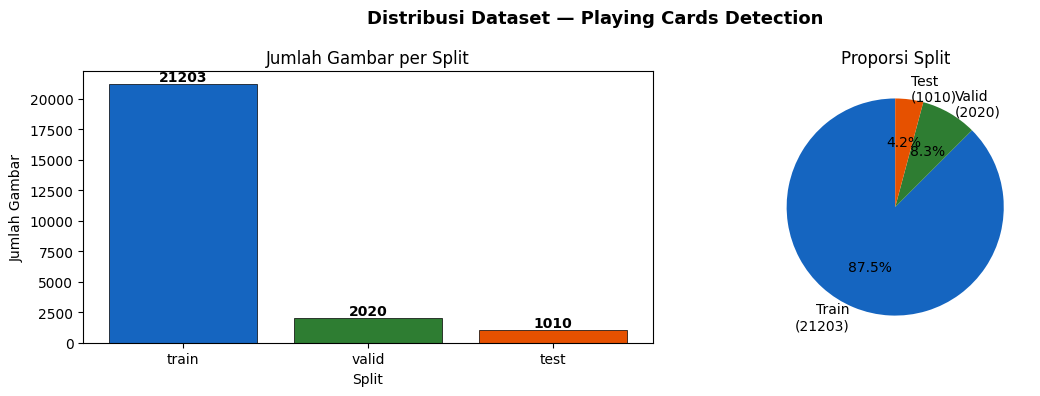

✅ Plot distribusi dataset tersimpan


In [ ]:
# Visualisasi distribusi split dataset
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribusi Dataset — Playing Cards Detection', fontsize=13, fontweight='bold')

colors = ['#1565C0', '#2E7D32', '#E65100']

# Bar chart
bars = axes[0].bar(split_counts.keys(), split_counts.values(), color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Jumlah Gambar per Split')
axes[0].set_xlabel('Split')
axes[0].set_ylabel('Jumlah Gambar')
for bar, count in zip(bars, split_counts.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(count), ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(split_counts.values(), labels=[f'{k.capitalize()}\n({v})' for k, v in split_counts.items()],
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Proporsi Split')

plt.tight_layout()
plt.savefig('dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot distribusi dataset tersimpan')

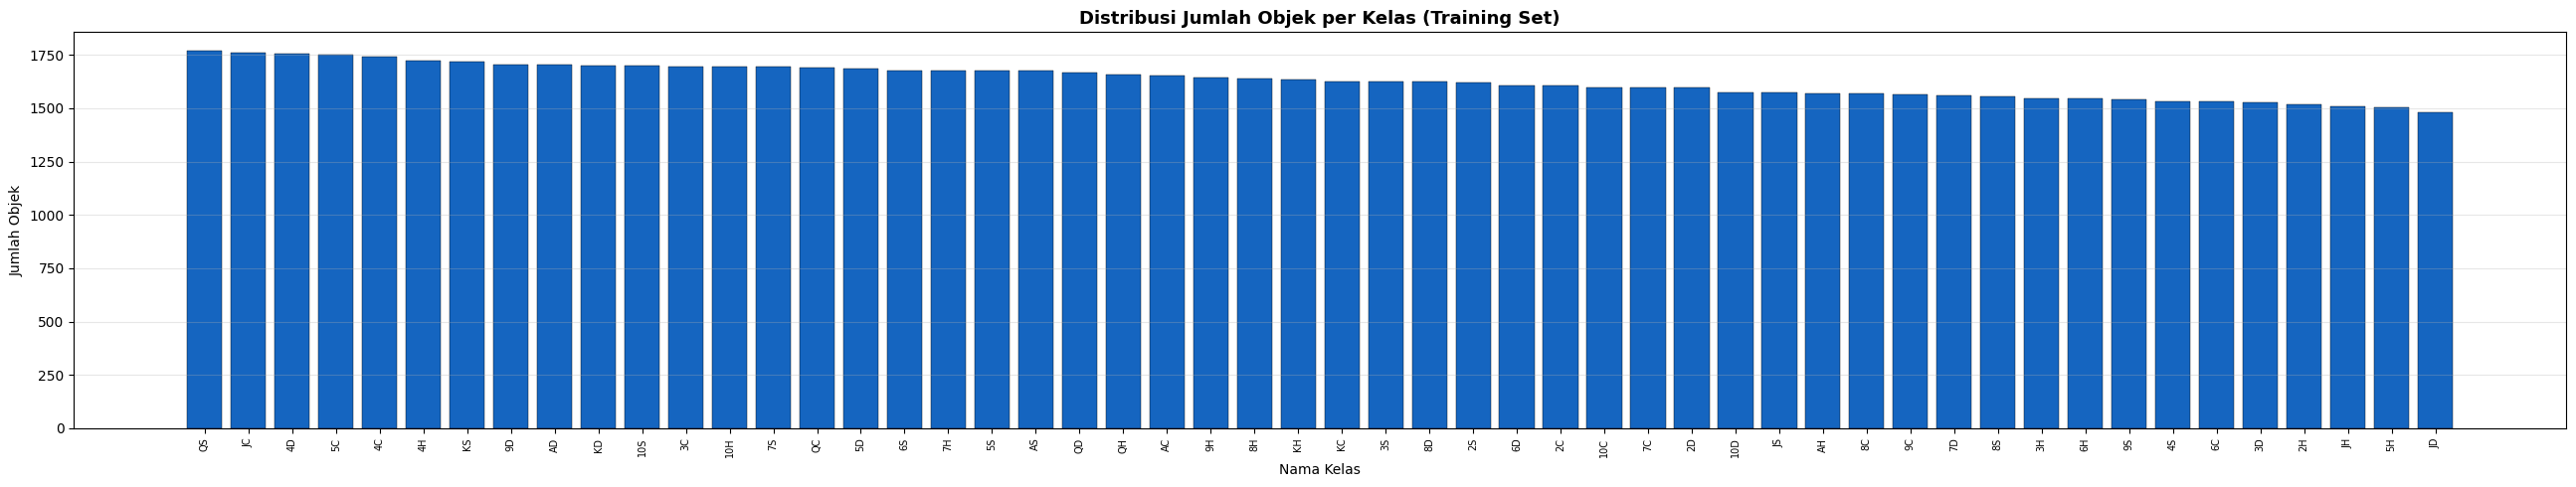

✅ Distribusi kelas tersimpan
   Total objek dalam training set: 84789


In [ ]:
# Hitung frekuensi tiap kelas di training set
train_lbl_dir = DATASET_PATH / 'train' / 'labels'
class_counts  = {i: 0 for i in range(num_classes)}

for lbl_path in train_lbl_dir.glob('*.txt'):
    with open(lbl_path) as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                cls_id = int(parts[0])
                if cls_id in class_counts:
                    class_counts[cls_id] += 1

# Visualisasi distribusi kelas
sorted_classes = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
cls_ids   = [x[0] for x in sorted_classes]
cls_names = [class_names[i] if i < len(class_names) else str(i) for i in cls_ids]
cls_vals  = [x[1] for x in sorted_classes]

fig, ax = plt.subplots(figsize=(max(14, num_classes // 2), 5))
bars = ax.bar(range(len(cls_names)), cls_vals, color='#1565C0', edgecolor='black', linewidth=0.3)
ax.set_xticks(range(len(cls_names)))
ax.set_xticklabels(cls_names, rotation=90, fontsize=7)
ax.set_title('Distribusi Jumlah Objek per Kelas (Training Set)', fontsize=13, fontweight='bold')
ax.set_xlabel('Nama Kelas')
ax.set_ylabel('Jumlah Objek')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Distribusi kelas tersimpan')
print(f'   Total objek dalam training set: {sum(cls_vals)}')

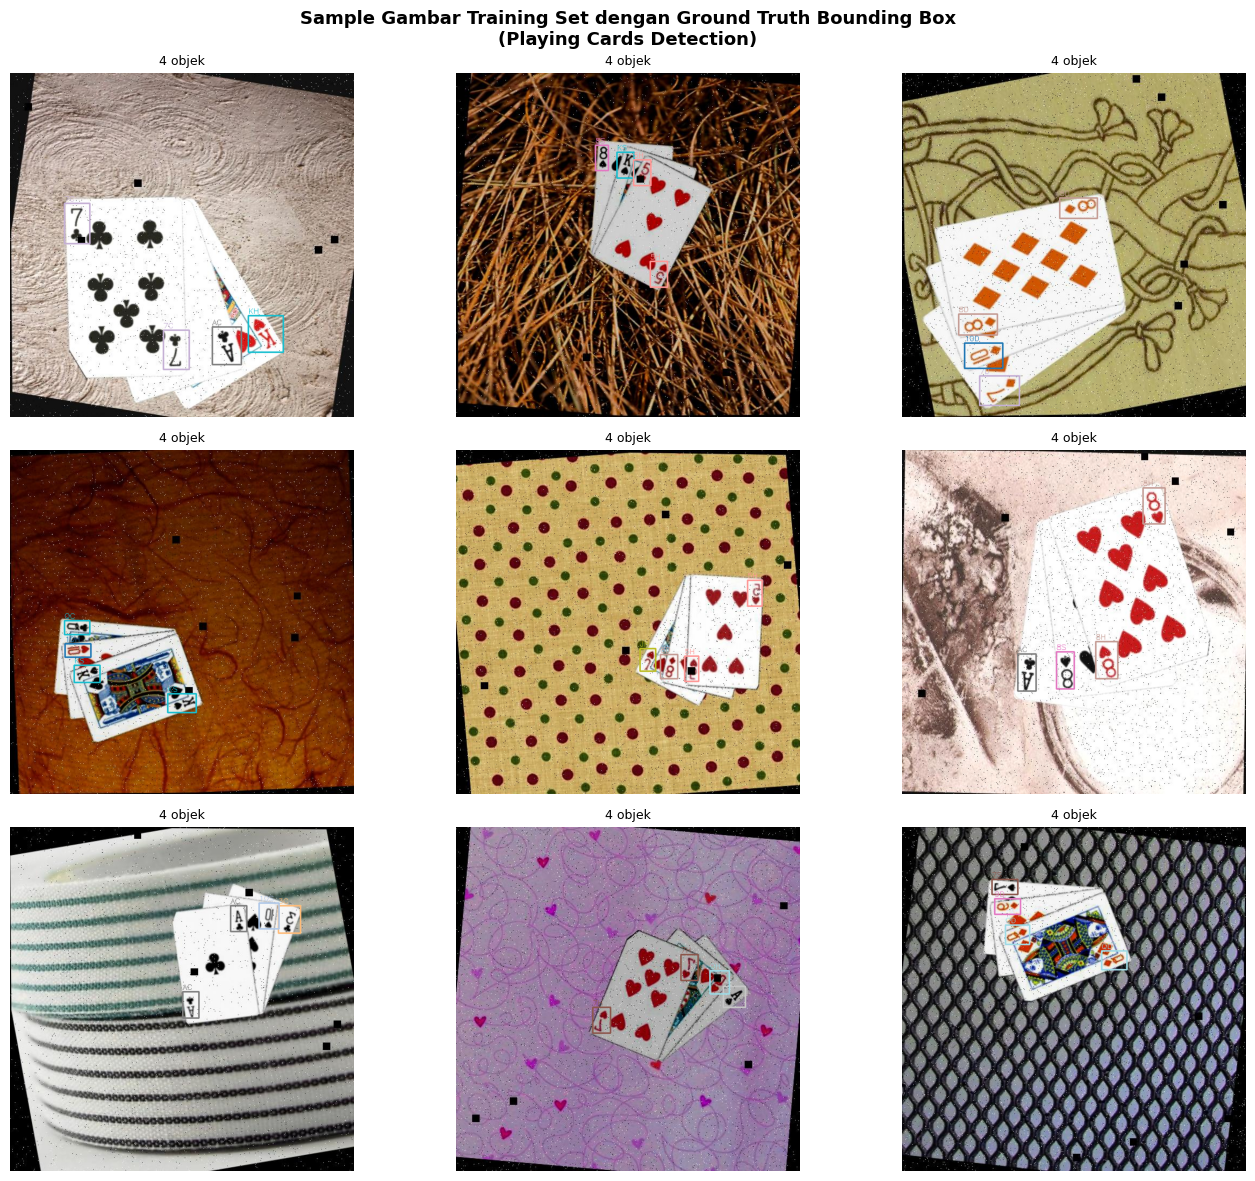

✅ Sample gambar dengan bounding box tersimpan


In [ ]:
# Visualisasi sample gambar dengan bounding box
train_img_dir = DATASET_PATH / 'train' / 'images'
sample_imgs   = random.sample(
    list(train_img_dir.glob('*.jpg')) + list(train_img_dir.glob('*.png')), 9
)

# Warna per kelas
palette = plt.cm.get_cmap('tab20', num_classes)
class_colors = {i: tuple(int(c * 255) for c in palette(i)[:3]) for i in range(num_classes)}

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
fig.suptitle('Sample Gambar Training Set dengan Ground Truth Bounding Box\n(Playing Cards Detection)',
             fontsize=13, fontweight='bold')

for ax, img_path in zip(axes.flatten(), sample_imgs):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    lbl_path = train_lbl_dir / (img_path.stem + '.txt')
    n_obj = 0
    if lbl_path.exists():
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    cls_id, xc, yc, bw, bh = int(parts[0]), *map(float, parts[1:])
                    x1 = int((xc - bw/2) * w)
                    y1 = int((yc - bh/2) * h)
                    x2 = int((xc + bw/2) * w)
                    y2 = int((yc + bh/2) * h)
                    color = class_colors.get(cls_id, (255, 0, 0))
                    cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
                    label = class_names[cls_id] if cls_id < len(class_names) else str(cls_id)
                    cv2.putText(img, label, (x1, max(y1-4, 10)),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)
                    n_obj += 1

    ax.imshow(img)
    ax.set_title(f'{n_obj} objek', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sample gambar dengan bounding box tersimpan')

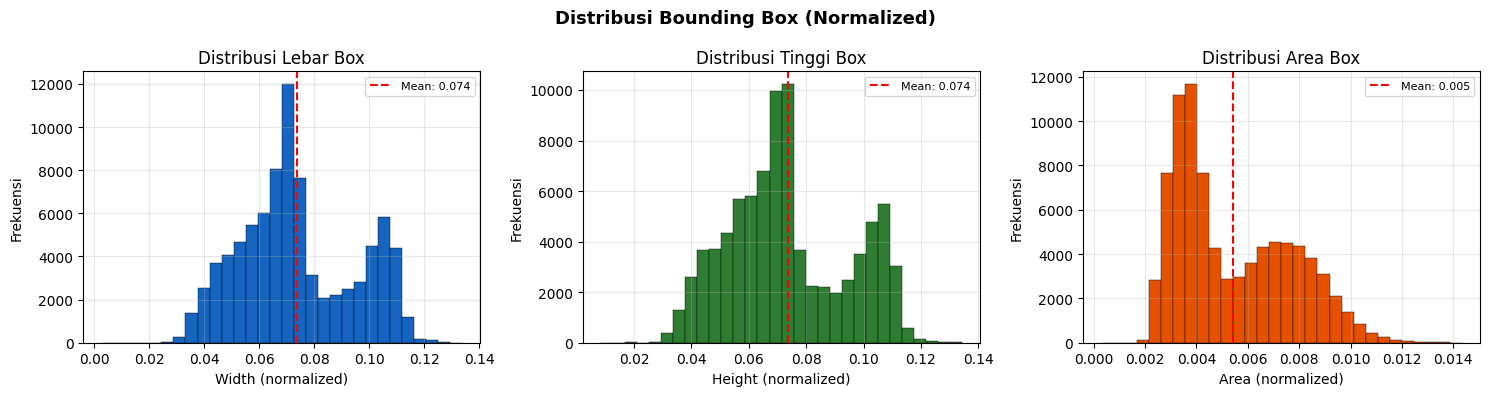

Total anotasi   : 84789
Rata-rata lebar : 0.0737
Rata-rata tinggi: 0.0735
Rata-rata area  : 0.0054


In [ ]:
# Analisis statistik bounding box
bbox_widths, bbox_heights, bbox_areas = [], [], []

for lbl_path in train_lbl_dir.glob('*.txt'):
    with open(lbl_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                _, xc, yc, bw, bh = map(float, parts)
                bbox_widths.append(bw)
                bbox_heights.append(bh)
                bbox_areas.append(bw * bh)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribusi Bounding Box (Normalized)', fontsize=13, fontweight='bold')

for ax, data, label, color in zip(
    axes,
    [bbox_widths, bbox_heights, bbox_areas],
    ['Width (normalized)', 'Height (normalized)', 'Area (normalized)'],
    ['#1565C0', '#2E7D32', '#E65100']
):
    ax.hist(data, bins=30, color=color, edgecolor='black', linewidth=0.3)
    ax.axvline(np.mean(data), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean: {np.mean(data):.3f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Frekuensi')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes[0].set_title('Distribusi Lebar Box')
axes[1].set_title('Distribusi Tinggi Box')
axes[2].set_title('Distribusi Area Box')

plt.tight_layout()
plt.savefig('bbox_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Total anotasi   : {len(bbox_widths)}')
print(f'Rata-rata lebar : {np.mean(bbox_widths):.4f}')
print(f'Rata-rata tinggi: {np.mean(bbox_heights):.4f}')
print(f'Rata-rata area  : {np.mean(bbox_areas):.4f}')

---
## 5. Preprocessing Data

In [ ]:
# Cek ukuran gambar yang ada di training set
sample_sizes = []
for img_path in list(train_img_dir.glob('*.jpg'))[:50] + list(train_img_dir.glob('*.png'))[:50]:
    img = cv2.imread(str(img_path))
    if img is not None:
        h, w = img.shape[:2]
        sample_sizes.append((w, h))

widths  = [s[0] for s in sample_sizes]
heights = [s[1] for s in sample_sizes]

print('Statistik Ukuran Gambar (sampel):')
print(f'  Lebar  — min: {min(widths)}, max: {max(widths)}, rata-rata: {np.mean(widths):.0f}')
print(f'  Tinggi — min: {min(heights)}, max: {max(heights)}, rata-rata: {np.mean(heights):.0f}')
print()
print('Konfigurasi Preprocessing YOLOv8:')
print('  Input size      : 640 × 640 px (auto resize + letterbox)')
print('  Normalisasi     : [0, 1] (otomatis)')
print()
print('Augmentasi Training (default YOLOv8):')
augs = [
    ('Mosaic',       'ON  — gabung 4 gambar'),
    ('Horizontal Flip', 'p = 0.5'),
    ('HSV Hue',      '0.015'),
    ('HSV Saturation', '0.7'),
    ('HSV Value',    '0.4'),
    ('Translate',    '0.1'),
    ('Scale',        '0.5'),
    ('MixUp',        'OFF (default)'),
]
for name, val in augs:
    print(f'  {name:20s}: {val}')

Statistik Ukuran Gambar (sampel):
  Lebar  — min: 640, max: 640, rata-rata: 640
  Tinggi — min: 640, max: 640, rata-rata: 640

Konfigurasi Preprocessing YOLOv8:
  Input size      : 640 × 640 px (auto resize + letterbox)
  Normalisasi     : [0, 1] (otomatis)

Augmentasi Training (default YOLOv8):
  Mosaic              : ON  — gabung 4 gambar
  Horizontal Flip     : p = 0.5
  HSV Hue             : 0.015
  HSV Saturation      : 0.7
  HSV Value           : 0.4
  Translate           : 0.1
  Scale               : 0.5
  MixUp               : OFF (default)


---
## 6. Training Model YOLOv8 (Sub-CPMK 6)

In [ ]:
# Load model pretrained YOLOv8s
# Gunakan 's' (small) karena playing cards punya banyak kelas, butuh kapasitas lebih dari 'n'
model = YOLO('yolov8s.pt')

n_params = sum(p.numel() for p in model.model.parameters())
print(f'✅ Model YOLOv8s dimuat')
print(f'   Jumlah parameter : {n_params:,}')
print(f'   Jumlah kelas     : {num_classes}')

✅ Model YOLOv8s dimuat
   Jumlah parameter : 11,166,560
   Jumlah kelas     : 52


In [ ]:
# Training
results = model.train(
    data     = str(DATA_YAML),
    epochs   = 50,
    imgsz    = 640,
    batch    = 16,
    patience = 10,          # early stopping
    device   = 0,           # GPU
    project  = 'runs',
    name     = 'playing_cards_det',
    exist_ok = True,
    verbose  = True
)

print('\n✅ Training selesai!')
print('   Best model: runs/playing_cards_det/weights/best.pt')

Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Playing-Cards-4/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=playing_cards_det, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

---
## 7. Evaluasi Model

In [ ]:
!find /kaggle/working/runs -name "best.pt"

/kaggle/working/runs/detect/runs/playing_cards_det/weights/best.pt


In [ ]:
# Load best model
best_model = YOLO('/kaggle/working/runs/detect/runs/playing_cards_det/weights/best.pt')

# Evaluasi pada validation set
val_results = best_model.val(
    data   = str(DATA_YAML),
    split  = 'val',
    imgsz  = 640,
    device = 0
)

print('\n📊 HASIL EVALUASI — Validation Set')
print('=' * 40)
print(f'  mAP@50     : {val_results.box.map50:.4f}')
print(f'  mAP@50-95  : {val_results.box.map:.4f}')
print(f'  Precision  : {val_results.box.mp:.4f}')
print(f'  Recall     : {val_results.box.mr:.4f}')
print('=' * 40)

Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,145,708 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1047.2±371.8 MB/s, size: 51.6 KB)
val: Scanning /kaggle/working/Playing-Cards-4/valid/labels.cache... 2020 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2020/2020 403.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 127/127 4.6it/s 27.5s0.2s
                   all       2020       8080      0.999          1      0.995      0.829
                   10C        129        172      0.999          1      0.995      0.837
                   10D        124        161      0.999          1      0.995      0.836
                   10H        103        148      0.999          1      0.995      0.845
                   10S        112        153      0.999          1      0.995      0.846
                    2

In [ ]:
# Evaluasi pada test set
test_results = best_model.val(
    data   = str(DATA_YAML),
    split  = 'test',
    imgsz  = 640,
    device = 0
)

print('\n📊 HASIL EVALUASI — Test Set')
print('=' * 40)
print(f'  mAP@50     : {test_results.box.map50:.4f}')
print(f'  mAP@50-95  : {test_results.box.map:.4f}')
print(f'  Precision  : {test_results.box.mp:.4f}')
print(f'  Recall     : {test_results.box.mr:.4f}')
print('=' * 40)

Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 701.4±63.6 MB/s, size: 59.4 KB)
val: Scanning /kaggle/working/Playing-Cards-4/test/labels.cache... 1010 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1010/1010 423.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 64/64 4.3it/s 14.8s0.2s
                   all       1010       4040      0.999          1      0.995      0.827
                   10C         53         77      0.998          1      0.995      0.858
                   10D         53         74      0.998          1      0.995      0.846
                   10H         41         54      0.998          1      0.995      0.831
                   10S         62         86      0.999          1      0.995      0.833
                    2C         65         86      0.999          1      0.995      0.811
                   

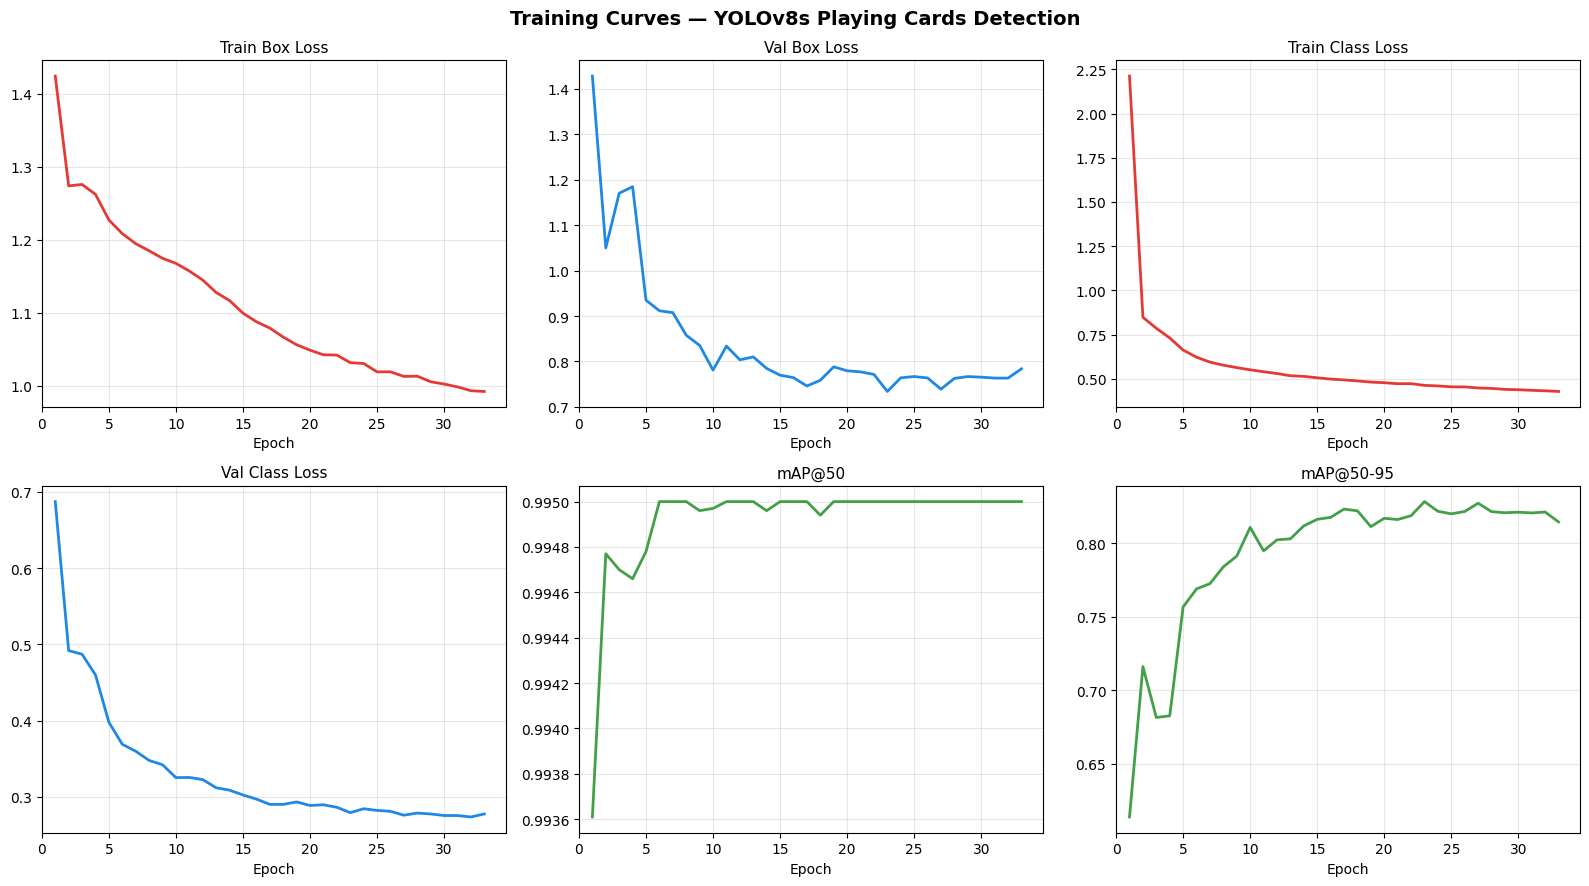

✅ Training curves berhasil ditampilkan


In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Update path ke lokasi hasil yang benar
results_csv = Path('/kaggle/working/runs/detect/runs/playing_cards_det/results.csv')

if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip() # Membersihkan spasi pada nama kolom

    metrics_to_plot = [
        ('train/box_loss', 'Train Box Loss', '#E53935'),
        ('val/box_loss', 'Val Box Loss', '#1E88E5'),
        ('train/cls_loss', 'Train Class Loss', '#E53935'),
        ('val/cls_loss', 'Val Class Loss', '#1E88E5'),
        ('metrics/mAP50(B)', 'mAP@50', '#43A047'),
        ('metrics/mAP50-95(B)', 'mAP@50-95', '#43A047'),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle('Training Curves — YOLOv8s Playing Cards Detection', fontsize=14, fontweight='bold')

    for ax, (col, title, color) in zip(axes.flatten(), metrics_to_plot):
        if col in df.columns:
            ax.plot(df['epoch'], df[col], color=color, linewidth=2)
            ax.set_title(title, fontsize=11)
            ax.set_xlabel('Epoch')
            ax.grid(True, alpha=0.3)
            ax.set_xlim(left=0)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Training curves berhasil ditampilkan')
else:
    print(f'❌ File tidak ditemukan di: {results_csv}')
    # Debugging: print isi folder untuk memastikan
    import os
    print("Isi folder:", os.listdir('/kaggle/working/runs/detect/runs/playing_cards_det/'))

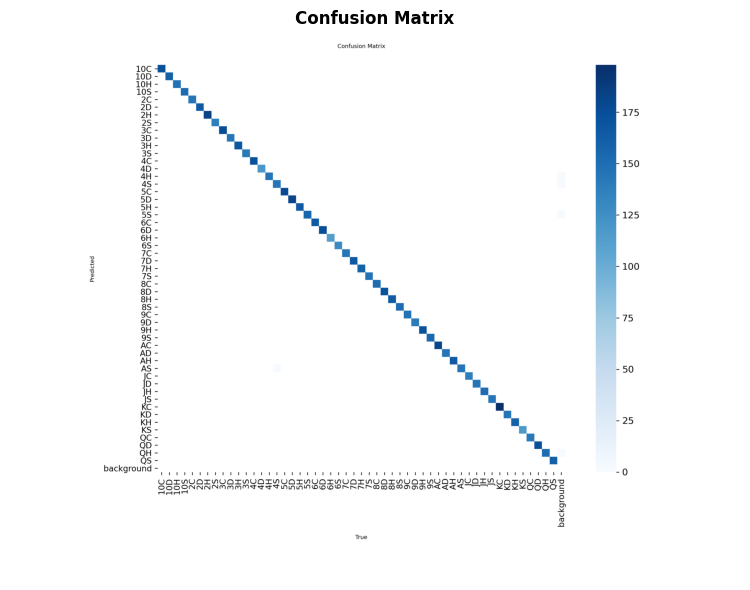

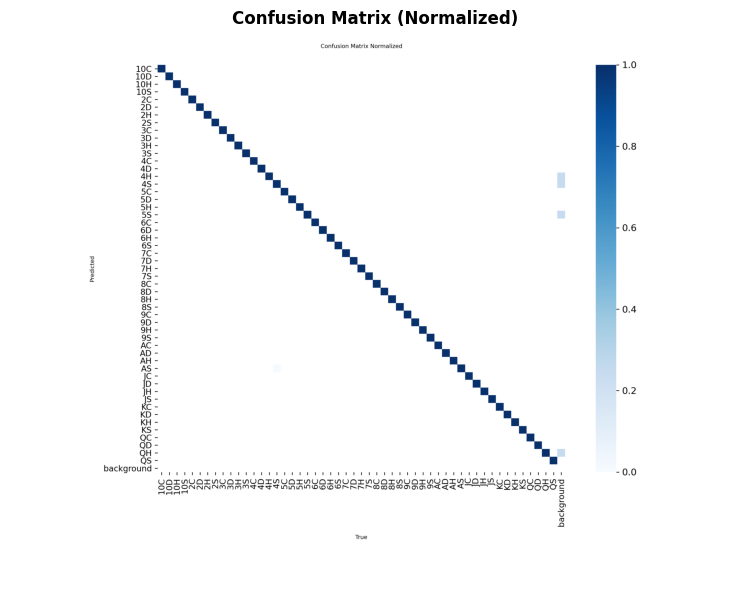

❌ File tidak ditemukan: /kaggle/working/runs/detect/runs/playing_cards_det/PR_curve.png
❌ File tidak ditemukan: /kaggle/working/runs/detect/runs/playing_cards_det/F1_curve.png


In [ ]:
run_dir = Path('/kaggle/working/runs/detect/runs/playing_cards_det')

files_to_plot = [
    ('confusion_matrix.png', 'Confusion Matrix'),
    ('confusion_matrix_normalized.png', 'Confusion Matrix (Normalized)'),
    ('PR_curve.png', 'Precision-Recall Curve'),
    ('F1_curve.png', 'F1 Curve')
]

for fname, title in files_to_plot:
    fpath = run_dir / fname
    if fpath.exists():
        img = plt.imread(str(fpath))
        plt.figure(figsize=(9, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.title(title, fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print(f'❌ File tidak ditemukan: {fpath}')

---
## 8. Visualisasi Hasil Prediksi

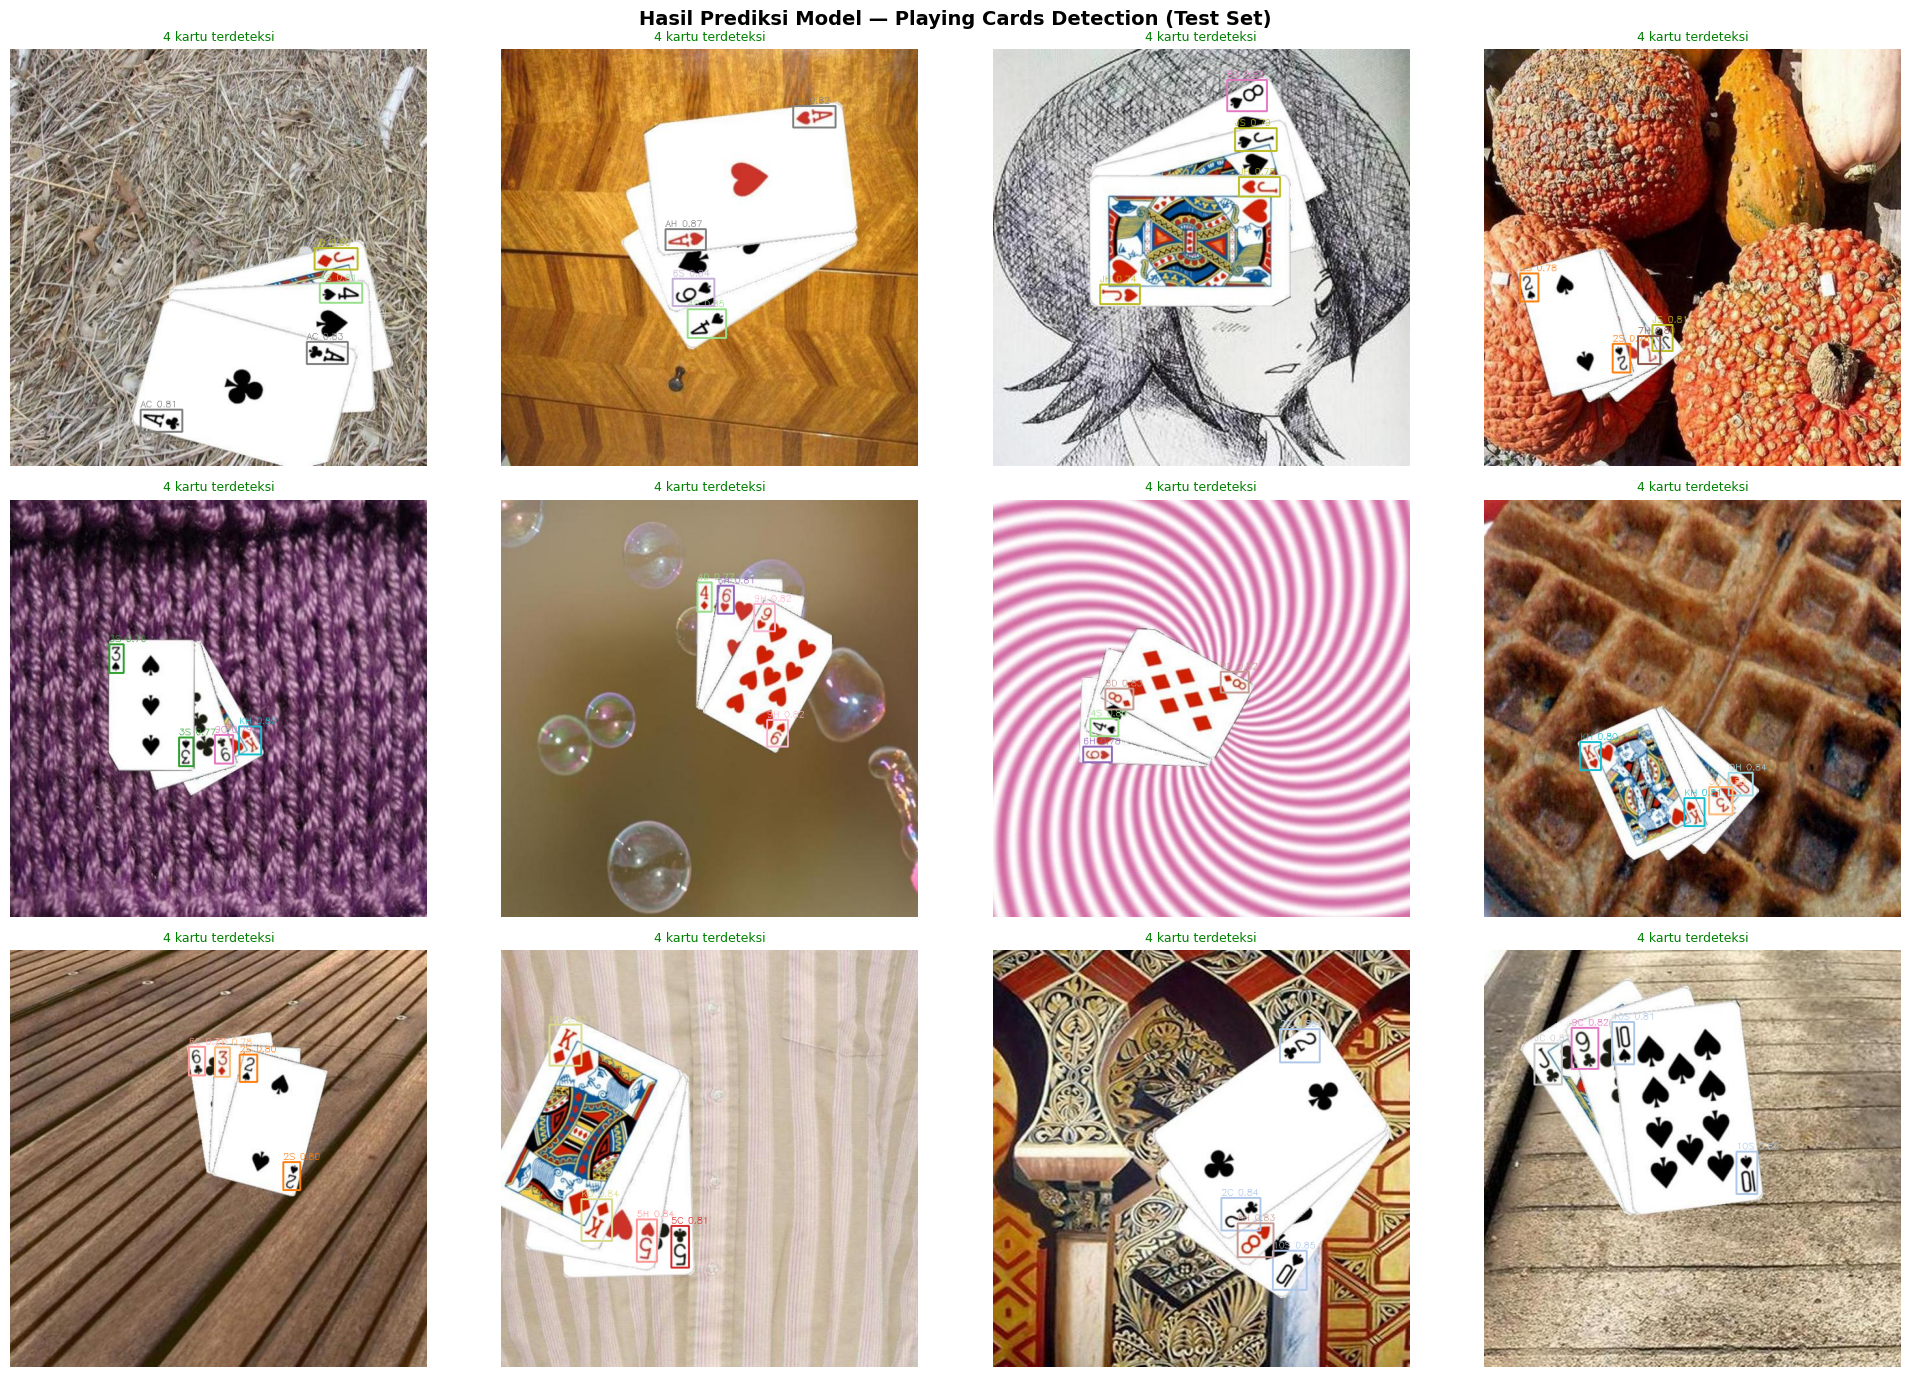

✅ Hasil prediksi tersimpan


In [ ]:
# Prediksi pada gambar test set
test_img_dir = DATASET_PATH / 'test' / 'images'
test_imgs    = list(test_img_dir.glob('*.jpg')) + list(test_img_dir.glob('*.png'))
sample_test  = random.sample(test_imgs, min(12, len(test_imgs)))

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
fig.suptitle('Hasil Prediksi Model — Playing Cards Detection (Test Set)',
             fontsize=14, fontweight='bold')

for ax, img_path in zip(axes.flatten(), sample_test):
    preds = best_model.predict(str(img_path), conf=0.25, verbose=False)
    pred  = preds[0]

    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    boxes  = pred.boxes
    n_det  = len(boxes)

    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        conf_score = float(box.conf[0])
        cls_id     = int(box.cls[0])
        color      = class_colors.get(cls_id, (0, 255, 0))
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        label = f'{class_names[cls_id] if cls_id < len(class_names) else cls_id} {conf_score:.2f}'
        cv2.putText(img, label, (x1, max(y1-4, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)

    ax.imshow(img)
    ax.set_title(f'{n_det} kartu terdeteksi', fontsize=9,
                 color='green' if n_det > 0 else 'red')
    ax.axis('off')

plt.tight_layout()
plt.savefig('prediction_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Hasil prediksi tersimpan')

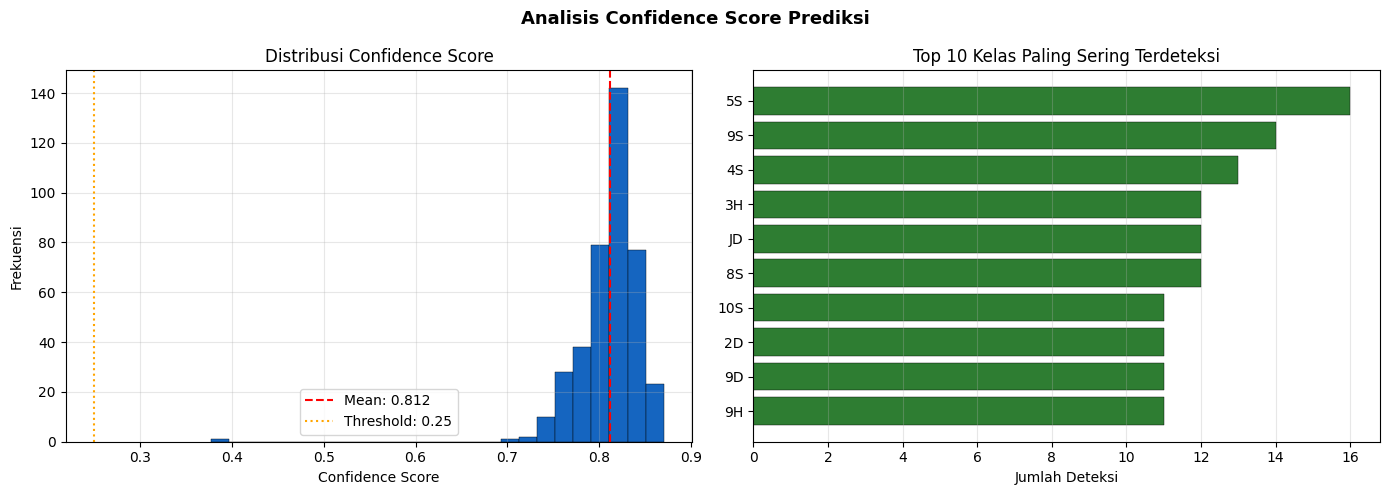

Total deteksi (conf ≥ 0.1) : 401
Rata-rata confidence         : 0.8118
Median confidence            : 0.8186


In [ ]:
# Analisis confidence score pada test set
all_confs   = []
all_cls_ids = []

for img_path in test_imgs[:100]:
    preds = best_model.predict(str(img_path), conf=0.1, verbose=False)
    for box in preds[0].boxes:
        all_confs.append(float(box.conf[0]))
        all_cls_ids.append(int(box.cls[0]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Analisis Confidence Score Prediksi', fontsize=13, fontweight='bold')

# Histogram confidence
axes[0].hist(all_confs, bins=25, color='#1565C0', edgecolor='black', linewidth=0.3)
axes[0].axvline(np.mean(all_confs), color='red', linestyle='--',
                label=f'Mean: {np.mean(all_confs):.3f}')
axes[0].axvline(0.25, color='orange', linestyle=':', label='Threshold: 0.25')
axes[0].set_title('Distribusi Confidence Score')
axes[0].set_xlabel('Confidence Score')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Top 10 kelas paling sering terdeteksi
from collections import Counter
top_classes = Counter(all_cls_ids).most_common(10)
top_names   = [class_names[c] if c < len(class_names) else str(c) for c, _ in top_classes]
top_counts  = [cnt for _, cnt in top_classes]
axes[1].barh(top_names[::-1], top_counts[::-1], color='#2E7D32', edgecolor='black', linewidth=0.3)
axes[1].set_title('Top 10 Kelas Paling Sering Terdeteksi')
axes[1].set_xlabel('Jumlah Deteksi')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('confidence_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Total deteksi (conf ≥ 0.1) : {len(all_confs)}')
print(f'Rata-rata confidence         : {np.mean(all_confs):.4f}')
print(f'Median confidence            : {np.median(all_confs):.4f}')

---
## 9. Ringkasan Hasil & Analisis

In [ ]:
map50_val  = val_results.box.map50
map50_test = test_results.box.map50

# Tabel perbandingan val vs test
summary = pd.DataFrame({
    'Metrik'    : ['mAP@50', 'mAP@50-95', 'Precision', 'Recall'],
    'Validation': [
        f'{val_results.box.map50:.4f}',
        f'{val_results.box.map:.4f}',
        f'{val_results.box.mp:.4f}',
        f'{val_results.box.mr:.4f}',
    ],
    'Test': [
        f'{test_results.box.map50:.4f}',
        f'{test_results.box.map:.4f}',
        f'{test_results.box.mp:.4f}',
        f'{test_results.box.mr:.4f}',
    ]
})

print('=' * 55)
print('        RINGKASAN HASIL EVALUASI MODEL')
print('=' * 55)
print(f'  Model     : YOLOv8s (pretrained COCO)')
print(f'  Dataset   : Playing Cards Detection v4')
print(f'  Kelas     : {num_classes} kelas')
print(f'  Input     : 640 × 640 px')
print(f'  Epochs    : 50 (early stopping p=10)')
print('=' * 55)
print(summary.to_string(index=False))
print('=' * 55)

# Simpan tabel
summary.to_csv('evaluation_summary.csv', index=False)

print('\nAnalisis:')
if map50_test >= 0.90:
    print('  ✅ Performa sangat baik — model mampu mengenali kartu remi dengan akurasi tinggi.')
elif map50_test >= 0.75:
    print('  ✅ Performa baik — model cukup andal mendeteksi kartu remi.')
elif map50_test >= 0.5:
    print('  ⚠️  Performa cukup — ada ruang peningkatan, coba tambah epoch atau gunakan YOLOv8m.')
else:
    print('  ❌ Performa rendah — pertimbangkan model lebih besar atau lebih banyak data.')

gap = abs(map50_val - map50_test)
if gap > 0.05:
    print(f'  ⚠️  Gap val–test: {gap:.4f} — kemungkinan terjadi overfitting ringan.')
else:
    print(f'  ✅ Gap val–test: {gap:.4f} — model generalisasi dengan baik.')

        RINGKASAN HASIL EVALUASI MODEL
  Model     : YOLOv8s (pretrained COCO)
  Dataset   : Playing Cards Detection v4
  Kelas     : 52 kelas
  Input     : 640 × 640 px
  Epochs    : 50 (early stopping p=10)
   Metrik Validation   Test
   mAP@50     0.9950 0.9950
mAP@50-95     0.8293 0.8272
Precision     0.9993 0.9985
   Recall     1.0000 1.0000

Analisis:
  ✅ Performa sangat baik — model mampu mengenali kartu remi dengan akurasi tinggi.
  ✅ Gap val–test: 0.0000 — model generalisasi dengan baik.


In [ ]:
# Kumpulkan semua output dan zip untuk didownload
from google.colab import files
import zipfile

output_files = [
    'dataset_distribution.png',
    'class_distribution.png',
    'sample_images.png',
    'bbox_distribution.png',
    'training_curves.png',
    'prediction_results.png',
    'confidence_analysis.png',
    'evaluation_summary.csv',
]

with zipfile.ZipFile('hasil_UAS_playing_cards.zip', 'w') as zf:
    for f in output_files:
        if Path(f).exists():
            zf.write(f)
            print(f'  + {f}')
    best_weights = 'runs/playing_cards_det/weights/best.pt'
    if Path(best_weights).exists():
        zf.write(best_weights)
        print(f'  + {best_weights}')

print('\n✅ Semua file terkumpul di hasil_UAS_playing_cards.zip')
files.download('hasil_UAS_playing_cards.zip')

  + dataset_distribution.png
  + class_distribution.png
  + sample_images.png
  + bbox_distribution.png
  + training_curves.png
  + prediction_results.png
  + confidence_analysis.png
  + evaluation_summary.csv

✅ Semua file terkumpul di hasil_UAS_playing_cards.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 10. Kesimpulan

Project ini mengimplementasikan **Object Detection** untuk mendeteksi dan mengklasifikasikan kartu remi menggunakan arsitektur **YOLOv8s** dengan transfer learning dari bobot pretrained COCO.

**Poin utama:**
- Dataset diambil dari Roboflow Universe — Augmented Startups (Playing Cards v4, format YOLOv8)
- Model dilatih selama 50 epoch dengan early stopping, input size 640×640, batch size 16 menggunakan GPU T4
- YOLOv8s dipilih karena dataset memiliki banyak kelas kartu sehingga butuh kapasitas model lebih besar dibanding YOLOv8n
- Evaluasi dilakukan pada validation set dan test set menggunakan mAP@50 dan mAP@50-95

**Potensi pengembangan:**
- Gunakan YOLOv8m/l untuk meningkatkan akurasi pada jumlah kelas yang besar
- Tambahkan pipeline deteksi real-time via webcam
- Integrasikan dengan sistem pengenalan permainan kartu otomatis